# Time evolution of quantum many-body systems using MPS
by Jose Javier Fernández González

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter as tpc
from pathlib import Path

## Part I
### Initial Definitions

First, we start by fixing the physical model, the initial product state, and the local operators used in all parts. We also define the Trotter gates that are reused later in both TEBD and transverse contraction, keeping conventions consistent across methods.


In [2]:
# Helper Funcitons
def dagger(A:np.array):
    return np.conjugate(A.T)

def mps_norm(mps):
    env = np.array([[1.0+0.0j]])
    for A in mps:
        Ac = np.conjugate(A)
        env = np.einsum('aA, a s b, A s B -> b B', env, A, Ac, optimize=True)
    return env[0, 0]

# Pauli Matrices we ar going to use
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

# Function for generating initial state and the operators in order to start clean on each simulation
def gen_mps_and_hamiltonian(N, g, dt):
    # Define intial state
    psi = [np.array((1.,0.)).reshape(1, 2, 1) for _ in range(N)]

    # Define Hamiltonian part by part
    ## Single particle diagonalized exp(-i*g*Z*dt)
    U1 = np.diag([np.exp(-1j * g * dt),np.exp(+1j * g * dt)])

    ## Two particles
    # diagonalize X_i X_i+1 using V exp(D) V_dagger
    evals, evecs = np.linalg.eigh( np.kron(X, X))
    D_vals = np.exp(-1j * evals * dt)
    U2 = evecs @  np.diag(D_vals) @ dagger(evecs)
    # reshape for tebd
    U2 = U2.reshape(2,2,2,2)

    return psi, U1, U2


### Time evolution
Next, we implement one full TEBD step by applying the one-site gate on every site and the two-site gate on alternating bonds, then compressing with SVD truncation to enforce the chosen bond-dimension cutoff.

In [3]:
# One timestep
def apply_time_step(psi, U1, U2, N, chi_max):
    ## Apply U1 on every site
    for i in range(N):
        psi[i] = np.einsum('Ss, a s b -> a S b', U1, psi[i], optimize=True)

    # Apply U2 on even and on odd bonds separately
    for bond in [0,1]: # 0 for even and 1 for odd
        for i in range(bond, N-1, 2):
            Ai = psi[i]
            Aj = psi[i+1]

            Dl = Ai.shape[0]
            Dr = Aj.shape[-1]

            # Merge and then apply U2
            theta = np.einsum('a s m, m t b -> a s t b', Ai, Aj, optimize=True)
            theta = np.einsum('S T s t, a s t b -> a S T b', U2, theta, optimize=True)

            # SVD and truncate
            theta_mat = theta.reshape(Dl * 2, 2 * Dr)
            U, eigenvals, V = np.linalg.svd(theta_mat, full_matrices=False)
            chi = min(chi_max, eigenvals.shape[0])
            U = U[:, :chi]
            eigenvals = eigenvals[:chi]
            V = V[:chi, :]

            # Absorb S into left tensor and reshape as mps
            US = U @ np.diag(eigenvals)

            psi[i]   = US.reshape(Dl, 2, chi)
            psi[i+1] = V.reshape(chi, 2, Dr)
    
    return psi

### Expectation Value
The contraction strategy used to evaluate local observables from the MPS is defined inserting the operator only at the target site while contracting identity everywhere esle

In [4]:
def compute_expectation_value(psi, operator, compute_index):
    # env to store calcs, start as identity of right size
    env = np.array([[1.0+0.0j]])

    for i, A in enumerate(psi):
        Ac = np.conjugate(A)

        if i == compute_index:
            # Insert operator at this index
            env = np.einsum('aA, a s b, A t B, t s -> b B',
                            env, A, Ac, operator,
                            optimize=True)
        else:
            # Omit operator
            env = np.einsum('aA, a s b, A s B -> b B',
                            env, A, Ac,
                            optimize=True)

    # At the end env should be scalar
    return env[0, 0]


### Complete run
After that, we combine initialization, repeated TEBD updates, and observable measurements into a full time-evolution routine that returns the normalized $\langle Z (t) \rangle$ trajectory

In [5]:
def run_sim_p1(N,g,dt,Tmax,chi_max):

    psi, U1, U2 = gen_mps_and_hamiltonian(N, g, dt)

    n_steps = int(round(Tmax / dt))
    mid = N // 2 - 1
    times = [0.0]
    z_vals = [compute_expectation_value(psi, Z, mid)]

    # time evolution loop
    for step in range(n_steps):
        t = (step + 1) * dt
        times.append(t)
        
        perf_time = tpc()
        psi = apply_time_step(psi, U1, U2, N, chi_max)
        # print(f"Progress t={t:2f}: applied timestep {step} time_wasted={tpc()-perf_time}s")

        perf_time = tpc()
        num = compute_expectation_value(psi, Z, mid)
        # print(f"Progress t={t:2f}: num={num} time_wasted={tpc()-perf_time}s")
        
        perf_time = tpc()
        den = mps_norm(psi)
        # print(f"Progress t={t:2f}: den={den} time_wasted={tpc()-perf_time}s")
        
        z_vals.append((num / den).real)

    return times, z_vals

In [6]:
# restore values if they exist, calculate and cache them if not
def get_part1(N, g, Tmax, dt, chi_max, cache_file):
    
    cache_file = Path(cache_file)

    if cache_file.exists():
        d = np.load(cache_file, allow_pickle=False)
        same_params = (
            int(d["N"]) == N
            and np.isclose(float(d["g"]), g)
            and np.isclose(float(d["Tmax"]), Tmax)
            and int(d["chi_max"]) == chi_max
            and np.isclose(float(d["dt"]), dt)
        )
        if same_params:
            return d["times"], d["z_vals"]

    times, z_vals = run_sim_p1(N, g, dt, Tmax, chi_max)

    np.savez(
        cache_file,
        N=N, g=g, Tmax=Tmax, chi_max=chi_max, dt=dt,
        times=np.asarray(times),
        z_vals=np.asarray(z_vals),
    )
    return np.asarray(times), np.asarray(z_vals)


Now we generate the dataset and plot 
$\langle Z_{N/2} (t) \rangle$

/home/neurona/venvs/jupyter/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/neurona/venvs/jupyter/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


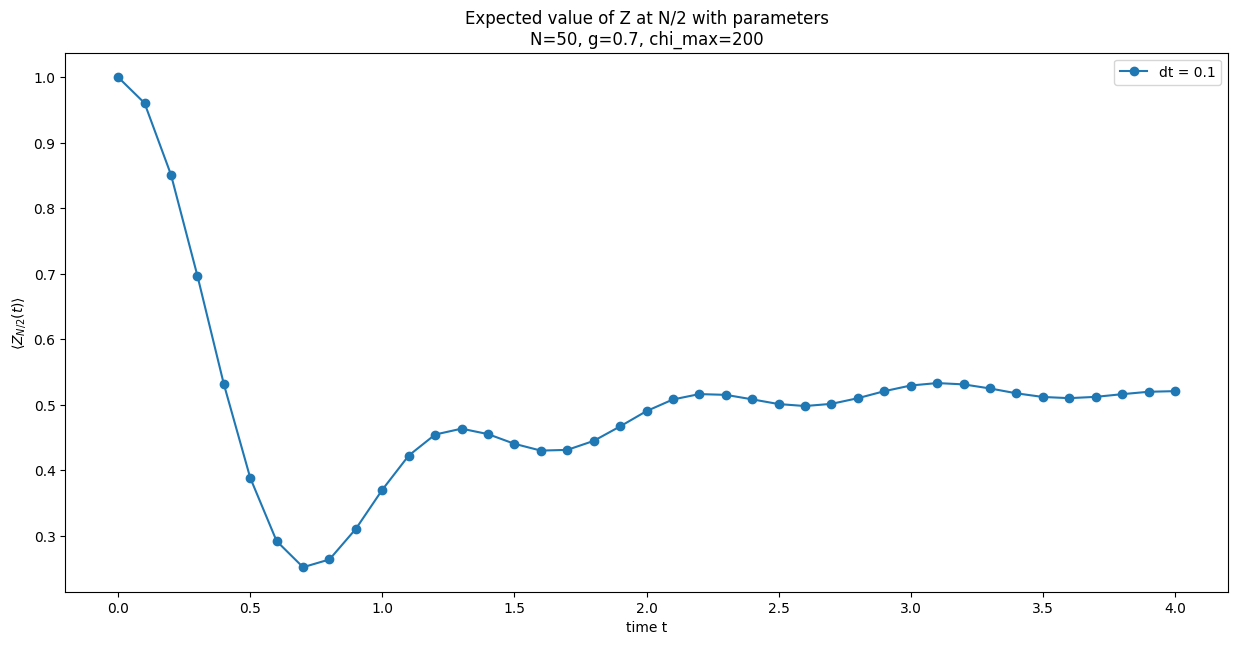

In [7]:
# Set parameters
N = 50
g = 0.7
Tmax = 4.0
chi_max = 200
dt = 0.1

# Run Sim
cache_file = "tebd_data_dt_0dot1.npz"
times_tebd, z_vals_tebd = get_part1(N, g, Tmax,dt, chi_max, cache_file)

plt.figure(figsize=(15,7))
plt.plot(times_tebd, z_vals_tebd, marker='o', label=f"dt = {dt}")
# plt.plot(times_dt2, z_vals_dt2, marker='x', label=f"dt = {dt2}", color='orange', alpha=0.75)
plt.xlabel("time t")
plt.ylabel(r"$\langle Z_{N/2}(t)\rangle$")
plt.title(f"Expected value of Z at N/2 with parameters\nN={N}, g={g}, chi_max={chi_max}")
plt.legend()
plt.show()

## Part II

### Transfer Matrices 
Now we need to take the columns of the tensor network as transfer matrices E in MPO representation. First we take the two body hamiltonian $U_2=X_i X_{i+1}$ and decompose it into the MPO shape. Then build the local transfer matrix.

In [8]:
def gen_transfer_matrix_mpo(U1, U2, N, x, n_steps, layer_seq=("u1", "even", "odd")):
    # Convert SVD to MPO parts
    d = U1.shape[0]
    M = np.transpose(U2, (0, 2, 1, 3)).reshape(d * d, d * d)
    U, eigvals, Vh = np.linalg.svd(M, full_matrices=False)
    # remove small values and convert to A and B tensors
    big_values = eigvals > 1e-14
    U = U[:, big_values]
    eigvals = eigvals[big_values]
    Vh = Vh[big_values, :]
    sqrt_ev = np.sqrt(eigvals)
    A = (U*sqrt_ev[None, :]).reshape(d, d, -1)
    B = (sqrt_ev[:, None]*Vh).reshape(-1, d, d)

    # Original MPO tensors (wL, wR, s_out, s_in)
    W_A = np.transpose(A, (2, 0, 1))[None, :, :, :]
    W_B = B[:, None, :, :]
    W_1 = U1[None, None, :, :]
    W_I = np.eye(d)[None, None, :, :]

    def local_W(layer_name, site):
        if layer_name == "u1":
            return W_1

        if layer_name == "even":
            if (site % 2 == 0) and (site < N - 1):
                return W_A
            if site % 2 == 1:
                return W_B
            return W_I

        if layer_name == "odd":
            if (site % 2 == 1) and (site < N - 1):
                return W_A
            if (site % 2 == 0) and (site > 0):
                return W_B
            return W_I
    
    # Build local E changing virtual legs and physical legs
    def local_transfer_from_W(W):
        wl, wr, _, _ = W.shape
        E8 = np.einsum("abST,cdst->TtSsbdac", W, np.conjugate(W), optimize=True)
        return E8.reshape(d * d, d * d, wr * wr, wl * wl)

    Ecol = []
    for _ in range(n_steps):
        for layer in layer_seq:
            Ecol.append(local_transfer_from_W(local_W(layer, x)))

    return Ecol


### Boundaries
Now we construct left and right boundary states along the time direction, make transfer-MPO bond dimensions check, and propagate boundaries column by column with truncation and normalization.

In [9]:
def make_bonds_same_size(Ecol):
    D = max(max(E.shape[2], E.shape[3]) for E in Ecol)
    out = []

    for E in Ecol:
        vL, vR, p_out, p_in = E.shape
        Epad = np.zeros((vL, vR, D, D), dtype=E.dtype)

        if p_out == 1 and p_in == 1:
            # Identity channel should propagate every channel index unchanged.
            for a in range(D):
                Epad[:, :, a, a] = E[:, :, 0, 0]
        else:
            Epad[:, :, :p_out, :p_in] = E

        out.append(Epad)

    return out, D

# Up spin
def doubled_initial_vector(d):
    v = np.zeros(d * d)
    v[0] = 1.0
    return v


#Vectorized identity
def doubled_final_vector(d=2):
    v = np.zeros(d * d)
    for s in range(d):
        v[s * d + s] = 1.0
    return v


def make_time_boundary_mps(n_layers, phys_dim):
    e = np.zeros(phys_dim, dtype=complex)
    e[0] = 1.0
    A0 = e.reshape(1, phys_dim, 1)
    return [A0.copy() for _ in range(n_layers)]

# Apply evolution
def apply_mpo_to_time_mps(mps, mpo, v_init, v_final):
    out = []
    n = len(mps)
    for t, (A, W) in enumerate(zip(mps, mpo)):
        Wuse = W

        # Contract initial state
        if t == 0:
            Wuse = np.einsum("x,xyPp->yPp", v_init, Wuse, optimize=True)[None, :, :, :]

        # Contract final closure
        if t == n - 1:
            Wuse = np.einsum("xyPp,y->xPp", Wuse, v_final, optimize=True)[:, None, :, :]

        chiL, pin, chiR = A.shape
        vL, vR, pout, pin2 = Wuse.shape
        if pin != pin2:
            raise ValueError(f"Physical mismatch at t={t}: {pin} vs {pin2}")

        T = np.einsum("lpr,abPp->laPrb", A, Wuse, optimize=True)
        out.append(T.reshape(chiL * vL, pout, chiR * vR))

    return out


def truncate_time_mps(mps, chi_max, eps=1e-12):
    mps = [A.copy() for A in mps]

    for i in range(len(mps) - 1):
        A = mps[i]
        B = mps[i + 1]

        chiL, pA, _ = A.shape
        _, pB, chiR = B.shape

        theta = np.einsum("lpr,rqs->lpqs", A, B, optimize=True)
        M = theta.reshape(chiL * pA, pB * chiR)

        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        crit_index = min(chi_max, max(1, np.sum(S > eps)))
        U = U[:, :crit_index]
        S = S[:crit_index]
        Vh = Vh[:crit_index, :]
        mps[i] = U.reshape(chiL, pA, crit_index)
        mps[i + 1] = (np.diag(S) @ Vh).reshape(crit_index, pB, chiR)

    return mps


def clalculate_mps_norm(mps):
    env = np.array([[1.0 + 0.0j]])
    for A in mps:
        Ac = np.conjugate(A)
        env = np.einsum("ab,apc,bpd->cd", env, A, Ac, optimize=True)
    return env[0, 0]


def normalize_time_mps(mps, floor=1e-300, imag_tol=1e-10):
    n_raw = clalculate_mps_norm(mps)
    if abs(np.imag(n_raw)) > imag_tol:
        # Robust fallback when transverse truncation keeps a residual phase.
        n = float(np.abs(n_raw))
    else:
        n = float(np.real(n_raw))
    n = max(n, floor)
    mps = [A.copy() for A in mps]
    mps[0] /= np.sqrt(n)
    log_scale = 0.5 * np.log(n)
    return mps, log_scale


def apply_column_to_boundary(boundary_mps, Ecol, chi_max, v_init, v_final, normalize_each=True):
    Ecol_u, D = make_bonds_same_size(Ecol)

    if boundary_mps is None:
        boundary_mps = make_time_boundary_mps(len(Ecol_u), D)

    B = apply_mpo_to_time_mps(boundary_mps, Ecol_u, v_init=v_init, v_final=v_final)
    B = truncate_time_mps(B, chi_max=chi_max)

    if normalize_each:
        B, log_scale = normalize_time_mps(B)
    else:
        log_scale = 0.0

    return B, log_scale


def build_left_boundary(U1, U2, N, x_op, n_steps, chi_max=200, layer_seq=("u1", "even", "odd")):
    n_layers = n_steps * len(layer_seq)

    Eref = gen_transfer_matrix_mpo(U1, U2, N, 0, n_steps, layer_seq=layer_seq)
    _, D = make_bonds_same_size(Eref)

    L = make_time_boundary_mps(n_layers, D)
    v_init = doubled_initial_vector(d=U1.shape[0])
    v_final = doubled_final_vector(d=U1.shape[0])

    logs = []
    for x in range(0, x_op):
        Ecol = gen_transfer_matrix_mpo(U1, U2, N, x, n_steps, layer_seq=layer_seq)
        # Left boundary should propagate in transposed transfer direction
        Ecol_T = [np.transpose(E, (1, 0, 3, 2)) for E in Ecol]
        L, lg = apply_column_to_boundary(L, Ecol_T, chi_max=chi_max, v_init=v_init, v_final=v_final, normalize_each=True)
        logs.append(lg)

    return L, np.array(logs)


def build_right_boundary(U1, U2, N, x_op, n_steps, chi_max=200, layer_seq=("u1", "even", "odd")):
    n_layers = n_steps * len(layer_seq)

    Eref = gen_transfer_matrix_mpo(U1, U2, N, 0, n_steps, layer_seq=layer_seq)
    _, D = make_bonds_same_size(Eref)

    R = make_time_boundary_mps(n_layers, D)
    v_init = doubled_initial_vector(d=U1.shape[0])
    v_final = doubled_final_vector(d=U1.shape[0])

    logs = []
    for x in range(N - 1, x_op, -1):
        Ecol = gen_transfer_matrix_mpo(U1, U2, N, x, n_steps, layer_seq=layer_seq)
        R, lg = apply_column_to_boundary(R, Ecol, chi_max=chi_max, v_init=v_init, v_final=v_final, normalize_each=True)
        logs.append(lg)

    return R, np.array(logs)


def build_boundaries_partII2(U1, U2, N, x_op, n_steps, chi_max=200, layer_seq=("u1", "even", "odd")):
    L, logL = build_left_boundary(U1, U2, N, x_op, n_steps, chi_max=chi_max, layer_seq=layer_seq)
    R, logR = build_right_boundary(U1, U2, N, x_op, n_steps, chi_max=chi_max, layer_seq=layer_seq)
    return L, R, logL, logR


### Expected Value

Now we need to define the contraction strategy for finding the expected value at a specific time. Since the approach is going sideways in the tensor network, we have to construct the full network for the expected value with the correct number of timesteps each time, instead of having an evolved system and measuring it each time step.

So, once boundaries we have boundaries defined, we evaluate numerator and denominator by contracting left boundary, operator column, and right boundary.

In [10]:
def contract_left_E_right(L, Ecol, R, v_init, v_final, use_transpose_left=True):

    Ecol_u, _ = make_bonds_same_size(Ecol)
    env = np.ones((1, 1, 1))  # (lL, lR, vL)
    n = len(Ecol_u)

    for t, (Lt, Et, Rt) in enumerate(zip(L, Ecol_u, R)):
        Euse = Et

        if t == 0:
            Euse = np.einsum("x,xypq->ypq", v_init, Euse, optimize=True)[None, :, :, :]

        if t == n - 1:
            Euse = np.einsum("xypq,y->xpq", Euse, v_final, optimize=True)[:, None, :, :]

        Luse = Lt if use_transpose_left else np.conjugate(Lt)
        env = np.einsum("abc,apr,cdpq,bqs->rsd", env, Luse, Euse, Rt, optimize=True)

    return env.reshape(()).item()


def expectation_from_boundaries(L, R, Ecol, O, d=2, use_transpose_left=True):
    v_init = doubled_initial_vector(d=d)
    v_final_I = doubled_final_vector(d=d)
    v_final_O = O.T.reshape(d * d)

    den = contract_left_E_right(L, Ecol, R, v_init=v_init, v_final=v_final_I, use_transpose_left=use_transpose_left)
    num = contract_left_E_right(L, Ecol, R, v_init=v_init, v_final=v_final_O, use_transpose_left=use_transpose_left)

    return num / den, num, den


def expectation_Z_partII(U1, U2, N, x_op, n_steps, chi_max=200,
                         layer_seq=("u1", "even", "odd"),
                         use_transpose_left=True):
    #Start by building the boundary states
    L, R, logL, logR = build_boundaries_partII2(
        U1, U2, N, x_op, n_steps, chi_max=chi_max, layer_seq=layer_seq
    )

    Ecol = gen_transfer_matrix_mpo(U1, U2, N, x_op, n_steps, layer_seq=layer_seq)
    val, num, den = expectation_from_boundaries(
        L, R, Ecol, Z, d=U1.shape[0], use_transpose_left=use_transpose_left
    )

    return val, num, den, L, R, logL, logR


### Testing

In [ ]:
# Part II quickly test the first data points vs Part I
N = 50
g = 0.7
chi_max = 200
Tmax = 4.0
dt = 0.1
n_datapoints = 3

x_test = N // 2 - 1

psi, U1_test, U2_test = gen_mps_and_hamiltonian(N, g, dt)

for i in range(1,n_datapoints+1):
    part1_val = z_vals_tebd[i]
    t = times_tebd[i]

    part2_val, part2_num, part2_den, *_ = expectation_Z_partII(
        U1_test, U2_test, N, x_test, n_steps=i, chi_max=chi_max
    )

    part1_real = float(np.real(part1_val))
    part2_real = float(np.real(part2_val))

    print(f"Part I  <Z(t={t:.2f})> = {part1_real:.12f}")
    print(f"Part II <Z(t={t:.2f})> = {part2_real:.12f}")
    print(f"Absolute Error       = {abs(part2_real - part1_real):.3e}\n")

Part I  <Z(t=0.10)> = 0.960530497001
Part II <Z(t=0.10)> = 0.960530497001
Absolute Error       = 1.110e-16

Part I  <Z(t=0.20)> = 0.851275926010
Part II <Z(t=0.20)> = 0.851275926010
Absolute Error       = 7.772e-16

Part I  <Z(t=0.30)> = 0.697117935811
Part II <Z(t=0.30)> = 0.697117935811
Absolute Error       = 6.661e-16



## Part III
Now we get von Neumann  entangled entropies. The code is provided but no results were achieved during the time window because of code execution being too large.

In [ ]:
def get_entanglement_entropies(mps):
    entropies = []
    # Make a copy so we don't modify the original MPS in-place
    A_list = [A.copy() for A in mps]
    N_sites = len(A_list)
    
    # Sweep from left to right to left-orthogonalize and extract singular values
    for i in range(N_sites - 1):
        vL, p, vR = A_list[i].shape
        M = A_list[i].reshape(vL * p, vR)
        
        # Perform SVD
        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        
        # Entropy calculation
        # Normalize singular values to ensure the sum of squares is 1
        S_norm = S / np.linalg.norm(S)
        S2 = S_norm**2
        S2 = S2[S2 > 1e-14] # Drop zeros to avoid log(0) warnings
        entropy = -np.sum(S2 * np.log(S2))
        entropies.append(entropy)
        
        # Absorb S and Vh into the next tensor to maintain the state
        A_list[i] = U.reshape(vL, p, len(S))
        SVh = np.diag(S) @ Vh
        
        # A_list[i+1] has shape (vR, p2, vR2)
        A_list[i+1] = np.einsum('ab, bcd -> acd', SVh, A_list[i+1], optimize=True)
        
    return entropies

In [ ]:
# Assuming N, g, dt, Tmax, chi_max, and mid are defined as before
N = 50
g = 0.7
dt = 0.1
Tmax = 4.0
chi_max = 200
mid = N // 2 - 1

# Regenerate operators
_, U1, U2 = gen_mps_and_hamiltonian(N, g, dt)
n_steps = int(round(Tmax / dt))

# Contract the tensor network for T=4 to extract L and R
part2_val, part2_num, part2_den, L, R = expectation_Z_partII(
    U1, U2, N, mid, n_steps=n_steps, chi_max=chi_max
)

# Calculate entropies
entropies_L = get_entanglement_entropies(L)
entropies_R = get_entanglement_entropies(R)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(entropies_L, label='Left MPS (|L>)', marker='.')
plt.plot(entropies_R, label='Right MPS (|R>)', marker='.', alpha=0.7)
plt.xlabel('Bond Index (Temporal direction)')
plt.ylabel('Von Neumann Entropy')
plt.title(f'Entanglement Entropy across bonds of L and R (T={Tmax})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Loop over T to evaluate the max entropy
T_vals = np.arange(0.1, 4.1, 0.1)
max_entropies = []

for T in T_vals:
    steps_i = int(round(T / dt))
    
    # Run the transverse contraction up to the required steps
    *_, R_i = expectation_Z_partII(
        U1, U2, N, mid, n_steps=steps_i, chi_max=chi_max
    )
    
    ent_R = get_entanglement_entropies(R_i)
    if len(ent_R) > 0:
        max_entropies.append(max(ent_R))
    else:
        max_entropies.append(0.0)

# Plot max entropy scaling
plt.figure(figsize=(8, 5))
plt.plot(T_vals, max_entropies, 'o-', color='purple')
plt.xlabel('Final Time T')
plt.ylabel('Max Entanglement Entropy of |R>')
plt.title('Scaling of Maximum Entanglement Entropy with Time')
plt.grid(True)
plt.show()